In [1]:
#1: Import Libraries
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

In [2]:
#2: Load Test Data and Models

X_test = joblib.load("x_test.pkl")
y_test = joblib.load("y_test.pkl")

nb_model = joblib.load("navie_bayes_model.pkl")
lr_model = joblib.load("logistic_regression_model.pkl")
svm_model = joblib.load("svm_model.pkl")
rf_model = joblib.load("random_forest_model.pkl")

In [3]:
#3: Evaluation Function
def evaluate(model):
    y_pred = model.predict(X_test)
    
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision":precision_score(y_test, y_pred, average="weighted"),
        "Recall":recall_score(y_test, y_pred , average="weighted"),
        "F1 Score":f1_score(y_test, y_pred, average="weighted")
    }

In [4]:
#4: Compare all Models
results = pd.DataFrame({
    "Navie Bayes": evaluate(nb_model),
    "logistic Regression": evaluate(lr_model),
    "SVM": evaluate(svm_model),
    "Random Forest": evaluate(rf_model)
}).T
results

,Accuracy,Precision,Recall,F1 Score
Navie Bayes,0.908486,0.892031,0.908486,0.899103
logistic Regression,0.918415,0.904241,0.918415,0.908644
SVM,0.915886,0.900777,0.915886,0.906144
Random Forest,0.905676,0.889775,0.905676,0.896707


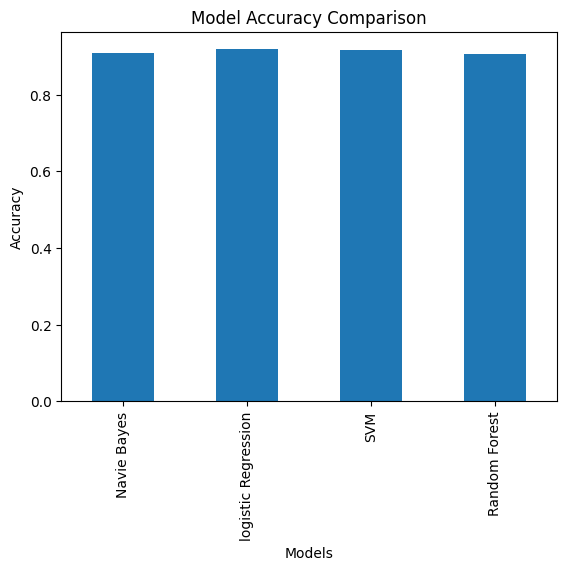

In [6]:
#5: Accuracy Comparison Chart

results["Accuracy"].plot(kind="bar")

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

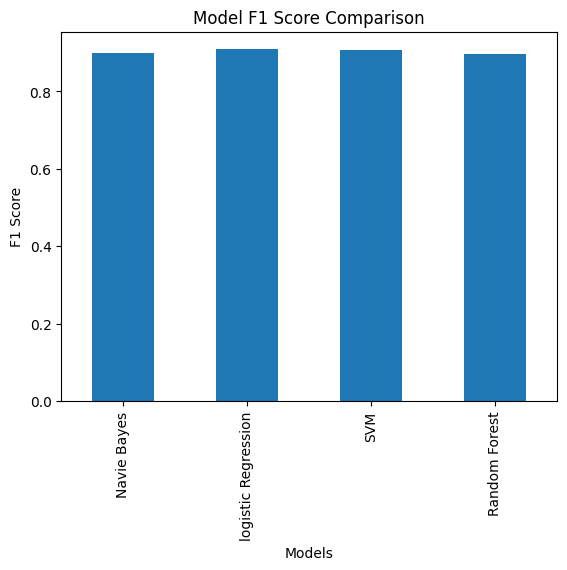

In [7]:
#6: F1 Score Comparison
results["F1 Score"].plot(kind="bar")

plt.title("Model F1 Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.show()


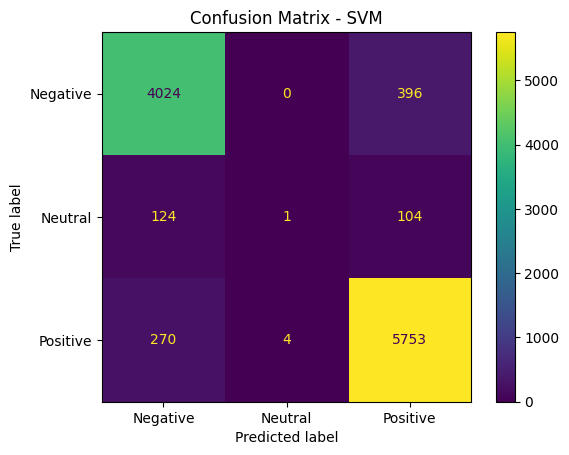

In [9]:
#7: Confusion Matrix for the Best Model
y_pred = svm_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix - SVM")
plt.show()

In [10]:
#8: Save Results to CSV
results.to_csv("model_evaluation_results.csv", index=True)